Figure 1

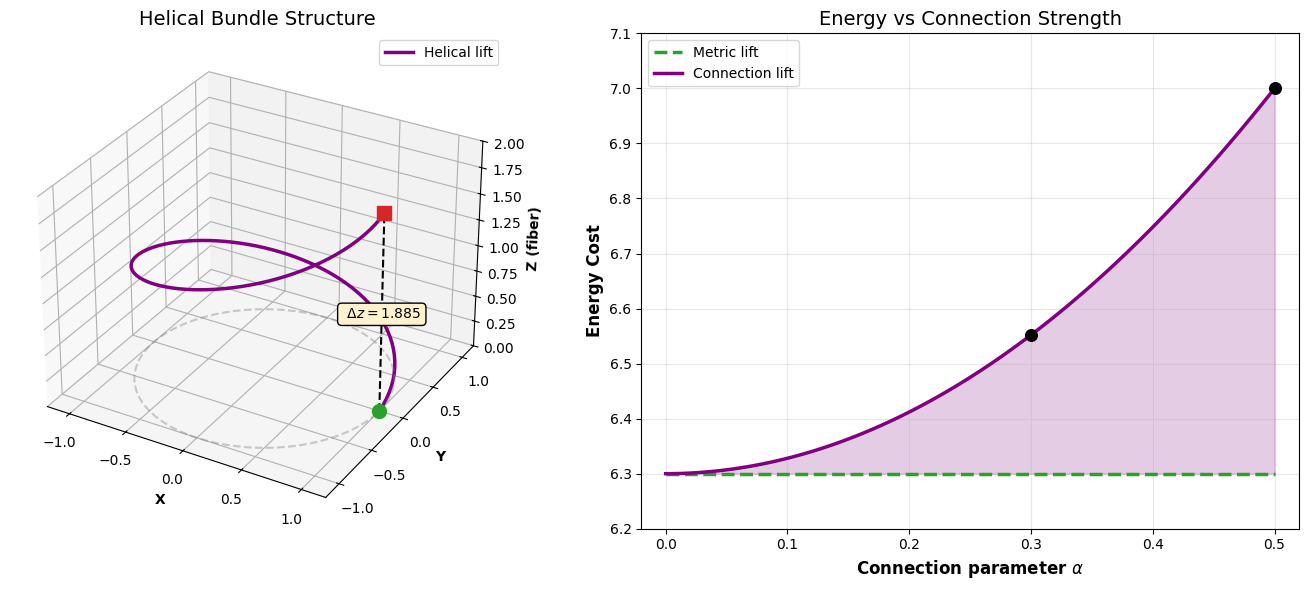

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# ==========================================
# Panel 1: Helical Bundle Structure
# ==========================================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Generate the Base Space Circle (X, Y)
t = np.linspace(0, 2*np.pi, 100)
x = np.cos(t)
y = np.sin(t)

# Generate the Vertical Lift (Z)
delta_z = 1.885
z = (t / (2*np.pi)) * delta_z

# Plot the 3D Helix
ax1.plot(x, y, z, color='purple', lw=2.5, label='Helical lift')

# Plot the 'shadow' (Metric projection on the base manifold)
ax1.plot(x, y, np.zeros_like(z), color='gray', alpha=0.4, linestyle='--')

# Markers for Start and End of the loop
ax1.scatter([1], [0], [0], color='#2ca02c', s=100, zorder=5) # Start (Green)
ax1.scatter([1], [0], [delta_z], color='#d62728', marker='s', s=100, zorder=5) # End (Red Square)

# Draw the vertical gap (Holonomy)
ax1.plot([1, 1], [0, 0], [0, delta_z], color='black', linestyle='--', lw=1.5)

# Add the Delta Z annotation box
ax1.text(1, 0, delta_z/2, r' $\Delta z = 1.885$ ',
         bbox=dict(facecolor='#fff2cc', edgecolor='black', boxstyle='round,pad=0.3'),
         ha='center', va='center', fontweight='bold')

# Clean up axes to match the original
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([0, 2.0])
ax1.set_xlabel('X', fontweight='bold')
ax1.set_ylabel('Y', fontweight='bold')
ax1.set_zlabel('Z (fiber)', fontweight='bold')
ax1.set_title('Helical Bundle Structure', fontsize=14)
ax1.legend(loc='upper right')

# ==========================================
# Panel 2: Energy vs Connection Strength
# ==========================================
ax2 = fig.add_subplot(1, 2, 2)

# Generate the Energy Curves
alpha_vals = np.linspace(0, 0.5, 100)
E_metric = np.full_like(alpha_vals, 6.3) # Flat baseline energy
E_connection = 6.3 + 2.8 * (alpha_vals ** 2) # Quadratic metabolic penalty

# Plot the lines
ax2.plot(alpha_vals, E_metric, color='#2ca02c', linestyle='--', lw=2.5, label='Metric lift')
ax2.plot(alpha_vals, E_connection, color='purple', lw=2.5, label='Connection lift')

# Fill the metabolic premium area
ax2.fill_between(alpha_vals, E_metric, E_connection, color='purple', alpha=0.2)

# Add the specific data point dots
highlight_alphas = [0.3, 0.5]
highlight_energies = [6.3 + 2.8 * (a ** 2) for a in highlight_alphas]
ax2.scatter(highlight_alphas, highlight_energies, color='black', s=70, zorder=5)

# Clean up axes
ax2.set_xlim([-0.02, 0.52])
ax2.set_ylim([6.2, 7.1])
ax2.set_xlabel(r'Connection parameter $\alpha$', fontweight='bold', fontsize=12)
ax2.set_ylabel('Energy Cost', fontweight='bold', fontsize=12)
ax2.set_title('Energy vs Connection Strength', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Run this to save a high-res copy for your paper:
# plt.savefig('Figure_1_Redraw.png', dpi=300, bbox_inches='tight')

Figure 2

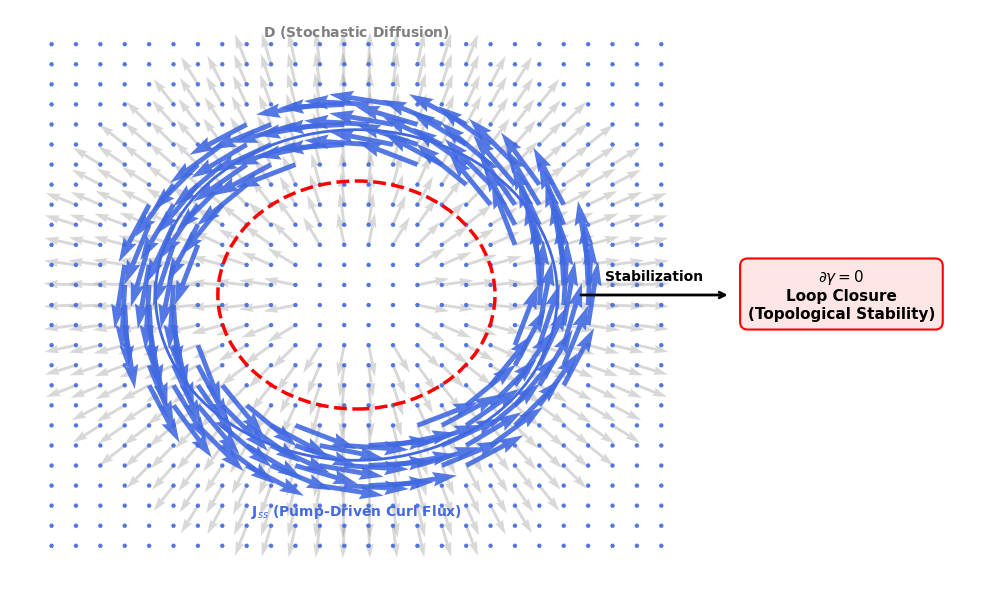

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 6))

# --- 1. Generate the Mathematical Vector Fields ---
# Using 26 points avoids hitting the exact (0,0) origin and prevents the divide-by-zero warning.
X, Y = np.meshgrid(np.linspace(-2.2, 2.2, 26), np.linspace(-2.2, 2.2, 26))
R = np.sqrt(X**2 + Y**2)

# Stochastic Diffusion Field (D) - Points outward (Entropy)
mask_D = (R > 0.4) & (R < 2.2)
U_D = X * mask_D / R
V_D = Y * mask_D / R
ax.quiver(X, Y, U_D, V_D, color='gray', alpha=0.3, scale=30, width=0.003)

# Pump-Driven Curl Flux Field (J_ss) - Points tangentially (Stirring)
mask_J = (R > 1.2) & (R < 1.7)
U_J = -Y * mask_J / R
V_J = X * mask_J / R
ax.quiver(X, Y, U_J, V_J, color='royalblue', scale=15, width=0.005, alpha=0.9)

# --- 2. Draw the Manifolds ---
# The Intentional Trajectory (Red Dashed Line)
circle_red = patches.Circle((0, 0), 1.0, edgecolor='red', facecolor='none', linestyle='--', linewidth=2.5, zorder=5)
ax.add_patch(circle_red)

# The NESS Stirring Boundary (Blue Solid Line)
circle_blue = patches.Circle((0, 0), 1.45, edgecolor='royalblue', facecolor='none', linewidth=2, zorder=5)
ax.add_patch(circle_blue)

# --- 3. Labels and Annotations ---
ax.text(0, 2.3, r"$\mathbf{D}$ (Stochastic Diffusion)", color='gray', ha='center', va='center', fontweight='bold')
ax.text(0, -1.9, r"$\mathbf{J}_{ss}$ (Pump-Driven Curl Flux)", color='royalblue', ha='center', va='center', fontweight='bold')

# The 'Stabilization' Arrow
ax.annotate("", xy=(2.7, 0), xytext=(1.6, 0),
            arrowprops=dict(arrowstyle="->", lw=2, color='black'))
ax.text(2.15, 0.1, "Stabilization", ha='center', va='bottom', fontsize=10, fontweight='bold')

# The Topological Stability Box
box_text = r"$\partial \gamma = 0$" + "\nLoop Closure\n(Topological Stability)"
ax.text(3.5, 0, box_text, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe6e6', edgecolor='red', lw=1.5),
        fontsize=11, fontweight='bold', zorder=10)

# --- 4. Final Formatting ---
ax.set_xlim(-2.5, 4.5)
ax.set_ylim(-2.5, 2.5)
ax.axis('off') # Hide the grid lines and box

plt.tight_layout()
plt.show()

# plt.savefig('Figure_2_Stirring_Fixed.png', dpi=300, bbox_inches='tight')

Figure 3

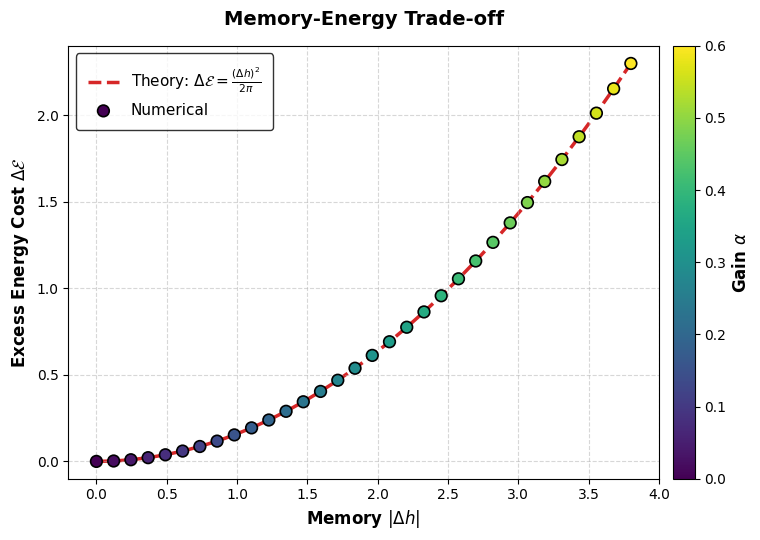

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 5.5))

# --- 1. Generate the Mathematical Data ---
# Delta h (Memory) from 0 to about 3.8
delta_h = np.linspace(0, 3.8, 32)

# Theoretical Energy Cost Curve: E = (h^2) / 2pi
E_theory = (delta_h**2) / (2 * np.pi)

# Gain alpha (Mapped to the colorbar, from 0.0 to 0.6)
alpha_gain = np.linspace(0.0, 0.6, len(delta_h))

# --- 2. Plot the Data ---
# The Theoretical Curve (Red Dashed Line)
ax.plot(delta_h, E_theory, color='#d62728', linestyle='--', linewidth=2.5, zorder=1,
        label=r'Theory: $\Delta\mathcal{E} = \frac{(\Delta h)^2}{2\pi}$')

# The Numerical Data (Scatter plot with colormap)
scatter = ax.scatter(delta_h, E_theory, c=alpha_gain, cmap='viridis',
                     edgecolors='black', linewidths=1.2, s=70, zorder=5,
                     label='Numerical')

# --- 3. Formatting and Labels ---
# Add the Colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r'Gain $\alpha$', fontweight='bold', fontsize=12)

# Axis Labels and Title
ax.set_xlabel(r'Memory $|\Delta h|$', fontweight='bold', fontsize=12)
ax.set_ylabel(r'Excess Energy Cost $\Delta\mathcal{E}$', fontweight='bold', fontsize=12)
ax.set_title('Memory-Energy Trade-off', fontweight='bold', fontsize=14, pad=15)

# Legend and Grid
ax.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=11, borderpad=0.8)
ax.grid(True, linestyle='--', alpha=0.5)

# Set precise limits to match the original scaling
ax.set_xlim(-0.2, 4.0)
ax.set_ylim(-0.1, 2.4)

plt.tight_layout()
plt.show()

# Run this to save a high-res copy:
# plt.savefig('Figure_3_Memory_Energy.png', dpi=300, bbox_inches='tight')